In [1]:
import sys, subprocess, os, time, gc, warnings
from pathlib import Path
from collections import defaultdict

REQUIRED = ["pandas", "numpy", "matplotlib", "seaborn",
            "statsmodels", "pyarrow", "psutil", "tqdm"]
for pkg in REQUIRED:
    try:
        __import__(pkg)
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

In [ ]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import psutil
from pathlib import Path
import os, time, gc, psutil, warnings
from collections import defaultdict
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from tqdm.auto import tqdm


warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
# plt.rcParams["figure.dpi"] = 100

c:\Users\favor\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# --- Paths (relative to notebook location — works on any OS) ---
BASE_DIR   = Path.cwd()
DATA_DIR   = BASE_DIR / "milan_data"
FIG_DIR    = BASE_DIR / "figures"
CACHE_DIR  = BASE_DIR / "cache"
for d in (FIG_DIR, CACHE_DIR):
    d.mkdir(exist_ok=True)

print(f"Base dir:   {BASE_DIR}")
print(f"Python:     {sys.version.split()[0]}")
print(f"Pandas:     {pd.__version__}")
print(f"Data dir: {DATA_DIR}")
print(f"Pandas:   {pd.__version__}")
ram = psutil.virtual_memory()
print(f"Total RAM:  {ram.total / 1024**3:.2f} GB")
print(f"Available:  {ram.available / 1024**3:.2f} GB")

Base dir:   c:\Users\favor\Downloads\trial_formative-1\trial_formative-1
Python:     3.10.8
Pandas:     2.3.3
Data dir: c:\Users\favor\Downloads\trial_formative-1\trial_formative-1\milan_data
Pandas:   2.3.3
Total RAM:  15.73 GB
Available:  1.28 GB


In [ ]:
# ============================================================
# CELL 2 — Locate the Milan .txt files & verify format
# ============================================================
# The Milan dataset is distributed as TAB-SEPARATED .txt files
# with no header row. Only .txt is supported by this notebook.

def find_files(data_dir):
    """Return sorted list of Milan daily .txt files."""
    files = sorted(data_dir.glob("sms-call-internet-mi-*.txt"))
    return [f for f in files if f.is_file()]


def detect_format(filepath):
    """Return (separator, has_header, column_names) for a Milan .txt file.

    Raises ValueError if the file is not tab-separated, so a malformed
    copy fails fast rather than silently mis-parsing.
    """
    with open(filepath, "r") as fh:
        first = fh.readline().rstrip("\n")

    if "\t" not in first:
        raise ValueError(
            f"Expected tab-separated Milan data, but found no tabs in: {filepath.name}"
        )
    sep = "\t"

    milan_cols = ["Square id", "Time Interval", "Country code",
                    "SMS-in activity", "SMS-out activity",
                    "Call-in activity", "Call-out activity",
                    "Internet traffic activity"]

    tokens = first.split(sep)
    try:
        float(tokens[0].strip())
        has_header = False
    except (ValueError, IndexError):
        has_header = True

    return sep, has_header, milan_cols


if not DATA_DIR.exists():
    raise FileNotFoundError(f"Folder not found: {DATA_DIR}")

txt_files = find_files(DATA_DIR)          # variable name kept for compatibility
if len(txt_files) == 0:
    raise FileNotFoundError(f"No .txt files found in {DATA_DIR}")

sample_file = txt_files[0]
SEP, HAS_HEADER, MILAN_COLS = detect_format(sample_file)

print(f"Found {len(txt_files)} .txt file(s)")
print(f"  First: {txt_files[0].name}")
print(f"  Last:  {txt_files[-1].name}")
total_gb = sum(f.stat().st_size for f in txt_files) / 1024**3
print(f"  Total size on disk: {total_gb:.2f} GB")
print(f"\nSeparator:  {repr(SEP)}")
print(f"Has header: {HAS_HEADER}")
print("\nFirst 3 raw lines of sample:")
with open(sample_file) as fh:
    for _ in range(3):
        line = fh.readline()
        if not line:
            break
        print(repr(line.rstrip()))

Found 62 file(s)
  First: sms-call-internet-mi-2013-11-01.txt
  Last:  sms-call-internet-mi-2014-01-01.txt
  Total size on disk: 19.38 GB

Separator:    '\t'
Has header:   False

First 3 raw lines of sample:
'1\t1383260400000\t0\t0.08136262351125882'
'1\t1383260400000\t39\t0.14186425470242922\t0.1567870050390246\t0.16093793691701822\t0.052274848528573205\t11.028366381681026'
'1\t1383261000000\t0\t0.13658782275823106\t\t\t0.02730046487718618'


In [ ]:
# ============================================================
# CELL 3 — Schema inspection on the first file
# ============================================================

print(f"Inspecting: {sample_file.name}\n")

# Read only the first 100k rows — fast and memory-light
sample = pd.read_csv(
    sample_file,
    sep=SEP,
    header=0 if HAS_HEADER else None,
    names=None if HAS_HEADER else MILAN_COLS,
    # nrows=100_000,
    engine="python",
)

print("--- Columns ---")
print(list(sample.columns))

print("\n--- dtypes ---")
print(sample.dtypes)

print("\n--- Missing values ---")
print(sample.isnull().sum())

print("\n--- Basic statistics ---")
print(sample.describe())

print(f"\nUnique Square IDs : {sample['Square id'].nunique()}")
print(f"Unique Country codes: {sample['Country code'].nunique()}")

# Convert Time Interval to datetime.
# Milan data uses Unix timestamps in milliseconds.
time_values = pd.to_numeric(
    sample["Time Interval"],
    errors="coerce"
)

time_dates = pd.to_datetime(
    time_values,
    unit="ms",
    errors="coerce"
)

print(
    f"Time range: "
    f"{time_dates.min()} "
    f"→ {time_dates.max()}"
)

Inspecting: sms-call-internet-mi-2013-11-01.txt

--- Columns ---
['Square id', 'Time Interval', 'Country code', 'SMS-in activity', 'SMS-out activity', 'Call-in activity', 'Call-out activity', 'Internet traffic activity']

--- dtypes ---
Square id                      int64
Time Interval                  int64
Country code                   int64
SMS-in activity              float64
SMS-out activity             float64
Call-in activity             float64
Call-out activity            float64
Internet traffic activity    float64
dtype: object

--- Missing values ---
Square id                          0
Time Interval                      0
Country code                       0
SMS-in activity              1981177
SMS-out activity             3210070
Call-in activity             3329423
Call-out activity            2611016
Internet traffic activity    2488626
dtype: int64

--- Basic statistics ---
          Square id  Time Interval  Country code  SMS-in activity  \
count  4.842625e+06   4.8

In [6]:
# ============================================================
# TASK 1.3 — Naive load: baseline memory & time
# ============================================================

def process_mem_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2

gc.collect()
mem_before = process_mem_mb()

t0 = time.time()
df_naive = pd.read_csv(
    sample_file,
    sep=SEP,
    header=0 if HAS_HEADER else None,
    names=None if HAS_HEADER else MILAN_COLS,
    engine="python",
)
t_naive = time.time() - t0

mem_after = process_mem_mb()
naive_mem = df_naive.memory_usage(deep=True).sum() / 1024**2

print(f"Naive load time        : {t_naive:.2f} s")
print(f"Process RSS increase   : {mem_after - mem_before:.1f} MB")
print(f"DataFrame memory (deep): {naive_mem:.1f} MB")
print(f"File size on disk      : {sample_file.stat().st_size/1024**2:.1f} MB")

print("\n--- Naive dtypes ---")
print(df_naive.dtypes)
print("\n--- df.info() ---")
df_naive.info()

Naive load time        : 33.94 s
Process RSS increase   : 196.6 MB
DataFrame memory (deep): 295.6 MB
File size on disk      : 307.9 MB

--- Naive dtypes ---
Square id                      int64
Time Interval                  int64
Country code                   int64
SMS-in activity              float64
SMS-out activity             float64
Call-in activity             float64
Call-out activity            float64
Internet traffic activity    float64
dtype: object

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4842625 entries, 0 to 4842624
Data columns (total 8 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   Square id                  int64  
 1   Time Interval              int64  
 2   Country code               int64  
 3   SMS-in activity            float64
 4   SMS-out activity           float64
 5   Call-in activity           float64
 6   Call-out activity          float64
 7   Internet traffic activity  float64
dt

In [ ]:
# ============================================================
# TASK 1.4 — Optimized loader with Parquet cache
# ============================================================

OPT_DTYPES = {
    "Square id":                  "int32",
    "Time Interval":              "int64",
    "Country code":               "int16",
    "SMS-in activity":            "float32",
    "SMS-out activity":           "float32",
    "Call-in activity":           "float32",
    "Call-out activity":          "float32",
    "Internet traffic activity":  "float32",
}
USECOLS = list(OPT_DTYPES.keys())


def load_optimized(filepath, use_parquet=True):
    """Load a single daily .txt with optimized dtypes; cache as Parquet."""
    filepath = Path(filepath)
    parquet_path = CACHE_DIR / (filepath.stem + ".parquet")

    # --- Parquet cache hit ---
    if use_parquet and parquet_path.exists():
        t0 = time.time()
        df = pd.read_parquet(parquet_path)
        return df, time.time() - t0, "parquet"

    # --- Load raw file with optimizations ---
    t0 = time.time()

    # Re-detect separator/header per file (cheap, robust)
    s, h, cols = detect_format(filepath)

    # Read only the columns we want — works for both header/no-header
    df = pd.read_csv(
        filepath,
        sep=s,
        header=0 if h else None,
        names=None if h else cols,
        usecols=USECOLS,
        dtype=OPT_DTYPES,
        engine="python",
    )

    # Datetime once
    df["Time Interval"] = pd.to_datetime(df["Time Interval"], unit="ms")
    df = df.rename(columns={"Time Interval": "datetime"})
    df = df.sort_values("datetime").reset_index(drop=True)
    load_time = time.time() - t0

    # --- Persist to Parquet ---
    if use_parquet:
        df.to_parquet(parquet_path, engine="pyarrow",
                        compression="snappy", index=False)

    return df, load_time, "raw"


# --- Benchmark ---
gc.collect()
mem_before_opt = process_mem_mb()
df_opt, t_opt, source = load_optimized(sample_file)
mem_after_opt = process_mem_mb()
opt_mem = df_opt.memory_usage(deep=True).sum() / 1024**2

# --- Parquet reload benchmark ---
gc.collect()
t0 = time.time()
df_pq = pd.read_parquet(CACHE_DIR / (sample_file.stem + ".parquet"))
t_pq = time.time() - t0
parquet_mb = (CACHE_DIR / (sample_file.stem + ".parquet")).stat().st_size / 1024**2

print(f"Source:                  {source}")
print(f"Optimized load time:     {t_opt:.2f} s")
print(f"DataFrame memory (deep): {opt_mem:.1f} MB")
print(f"Parquet reload time:     {t_pq:.2f} s")
print(f"Parquet file size:       {parquet_mb:.1f} MB")
print(f"Process RSS increase:    {mem_after_opt - mem_before_opt:.1f} MB")
print(f"DataFrame memory (deep): {opt_mem:.1f} MB")
print("\n--- Optimized dtypes ---")
print(df_opt.dtypes)

Source:                  parquet
Optimized load time:     1.21 s
DataFrame memory (deep): 157.0 MB
Parquet reload time:     0.17 s
Parquet file size:       61.9 MB
Process RSS increase:    396.7 MB
DataFrame memory (deep): 157.0 MB

--- Optimized dtypes ---
datetime                     datetime64[ns]
Square id                             int32
Country code                          int16
SMS-in activity                     float32
SMS-out activity                    float32
Call-in activity                    float32
Call-out activity                   float32
Internet traffic activity           float32
dtype: object


In [8]:
# ============================================================
# HELPER — Read one daily file with optional column subset
# ============================================================
def read_daily(filepath, usecols=None):
    filepath = Path(filepath)
    parquet_path = CACHE_DIR / (filepath.stem + ".parquet")

    # Translate requested usecols for the raw path
    if usecols is not None:
        raw_usecols = [("Time Interval" if c == "datetime" else c)
                        for c in usecols]
    else:
        raw_usecols = None

    # --- Parquet cache hit ---
    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
        if usecols is not None:
            df = df[usecols]
        return df

    # --- Raw file ---
    s, h, cols = detect_format(filepath)
    df = pd.read_csv(
        filepath,
        sep=s,
        header=0 if h else None,
        names=None if h else cols,
        usecols=raw_usecols if raw_usecols else USECOLS,
        dtype={k: v for k, v in OPT_DTYPES.items() if k in (raw_usecols or USECOLS)},
        engine="python",
    )
    if "Time Interval" in df.columns:
        df["Time Interval"] = pd.to_datetime(df["Time Interval"], unit="ms")
        df = df.rename(columns={"Time Interval": "datetime"})
    return df

In [ ]:
# ============================================================
# CELL 7 — Pre-cache all daily files (one-time, speeds up everything)
# ============================================================
# Reading a raw 300 MB tab file takes ~40 s; Parquet reload ~0.3 s.
# This loop pays that cost once so all later cells run fast.

already_cached = sum(
    1 for f in txt_files
    if (CACHE_DIR / (f.stem + ".parquet")).exists()
)
print(f"Already cached: {already_cached}/{len(txt_files)} files")

if already_cached < len(txt_files):
    for f in tqdm(txt_files, desc="Caching to Parquet"):
        parquet_path = CACHE_DIR / (f.stem + ".parquet")
        if parquet_path.exists():
            continue
        df_tmp, _, _ = load_optimized(f, use_parquet=True)
        del df_tmp
        gc.collect()

print(f"\nAll {len(txt_files)} files cached.")
cache_gb = sum(p.stat().st_size for p in CACHE_DIR.glob("sms-*.parquet")) / 1024**3
print(f"Total Parquet cache: {cache_gb:.2f} GB")

Already cached: 56/62 files


Caching to Parquet: 100%|██████████| 62/62 [03:47<00:00,  3.68s/it]


All 62 files cached.
Total Parquet cache: 3.84 GB


In [10]:
# ============================================================
# TASK 1.5 — Comparison table
# ============================================================

parquet_size_mb = (CACHE_DIR / (sample_file.stem + ".parquet")).stat().st_size / 1024**2

comparison = pd.DataFrame([
    {"Strategy": "Naive TXT (float64 / int64)",
    "Load time (s)":      round(t_naive, 3),
    "DataFrame mem (MB)": round(naive_mem, 1),
    "Disk size (MB)":     round(sample_file.stat().st_size / 1024**2, 1),
    "Notes": "All columns, default dtypes"},

    {"Strategy": "Optimized TXT (float32 / int32 / usecols)",
    "Load time (s)":      round(t_opt, 3),
    "DataFrame mem (MB)": round(opt_mem, 1),
    "Disk size (MB)":     round(sample_file.stat().st_size / 1024**2, 1),
    "Notes": "Only needed columns, downcast dtypes"},

    {"Strategy": "Parquet (snappy)",
    "Load time (s)":      round(t_pq, 3),
    "DataFrame mem (MB)": round(df_pq.memory_usage(deep=True).sum() / 1024**2, 1),
    "Disk size (MB)":     round(parquet_mb, 1),
    "Notes": "Columnar + compressed, fast reload"},
]).set_index("Strategy")

print("=" * 90)
print("MEMORY & LOAD-TIME COMPARISON (single daily file)")
print("=" * 90)
display(comparison)

reduction = (1 - opt_mem / naive_mem) * 100
disk_reduction = (1 - parquet_mb / (sample_file.stat().st_size / 1024**2)) * 100

print(f"\nMemory reduction (optimized vs naive): {reduction:.1f}%")
print(f"Disk  reduction (Parquet vs TXT):      {disk_reduction:.1f}%")
print(f"Load time speed-up (Parquet vs TXT):   {t_opt / t_pq:.1f}×")

MEMORY & LOAD-TIME COMPARISON (single daily file)


,Load time (s),DataFrame mem (MB),Disk size (MB),Notes
Strategy,,,,
Naive TXT (float64 / int64),33.937,295.6,307.9,"All columns, default dtypes"
Optimized TXT (float32 / int32 / usecols),1.211,157.0,307.9,"Only needed columns, downcast dtypes"
Parquet (snappy),0.167,157.0,61.9,"Columnar + compressed, fast reload"



Memory reduction (optimized vs naive): 46.9%
Disk  reduction (Parquet vs TXT):      79.9%
Load time speed-up (Parquet vs TXT):   7.2×


In [11]:
# ============================================================
# TASK 2.1 (part 1) — Aggregate total Internet traffic per area
# ============================================================
# Streams one file at a time → peak RAM ~ 500 MB regardless of
# dataset size. Uses the Parquet cache from Cell 5 for speed.
# ============================================================

AGG_CACHE = CACHE_DIR / "total_traffic_per_area.parquet"

def aggregate_total_traffic(files):
    if AGG_CACHE.exists():
        print(f"Loading cached aggregation: {AGG_CACHE.name}")
        s = pd.read_parquet(AGG_CACHE).set_index("Square id")["total_traffic"]
        s.index.name = "Square id"
        return s.sort_values(ascending=False)

    totals = defaultdict(float)
    for f in tqdm(files, desc="Aggregating"):
        df = read_daily(
            f,
            usecols=["Square id", "Internet traffic activity"],
        )
        # Cast defensively in case the raw path returned float64
        df["Square id"] = df["Square id"].astype("int32")
        df["Internet traffic activity"] = df["Internet traffic activity"].astype("float32")

        grouped = df.groupby("Square id")["Internet traffic activity"].sum()
        for sid, val in grouped.items():
            totals[sid] += float(val)

        del df, grouped
        gc.collect()

    result = (pd.Series(totals, name="total_traffic")
                .sort_values(ascending=False))
    result.index.name = "Square id"
    result.reset_index().to_parquet(AGG_CACHE)
    print(f"Cached aggregation → {AGG_CACHE.name}")
    return result

# --- RUN the aggregation ---
t0 = time.time()
total_traffic = aggregate_total_traffic(txt_files)
print(f"\nAggregation time: {time.time() - t0:.1f} s")
print(f"Areas with traffic : {len(total_traffic):,}")
print(f"Grand total CDRs   : {total_traffic.sum():,.0f}")
print("\nTop 10 areas:")
print(total_traffic.head(10).to_string())

Aggregating: 100%|██████████| 62/62 [00:29<00:00,  2.11it/s]

Cached aggregation → total_traffic_per_area.parquet

Aggregation time: 29.4 s
Areas with traffic : 10,000
Grand total CDRs   : 5,552,894,187

Top 10 areas:
Square id
5161    1.274006e+07
5059    1.117085e+07
5259    1.048578e+07
5061    9.584334e+06
5258    8.707440e+06
5159    8.703873e+06
6064    8.675343e+06
4855    8.491044e+06
4856    8.230212e+06
5262    8.163357e+06


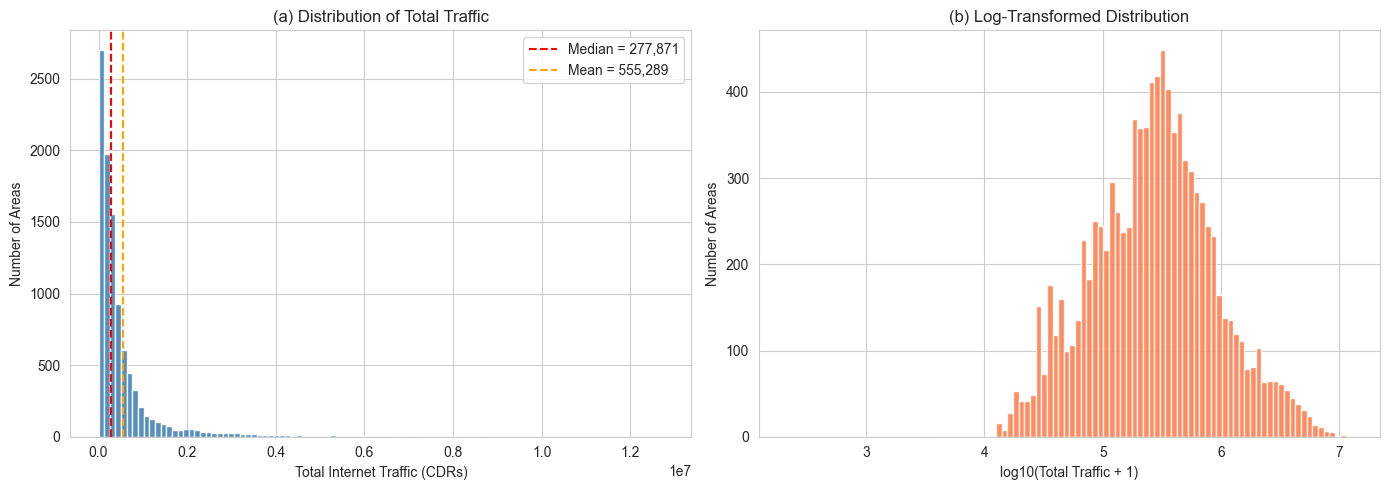

DISTRIBUTION STATISTICS
count    1.000000e+04
mean     5.552894e+05
std      8.925957e+05
min      2.136265e+02
25%      1.181020e+05
50%      2.778711e+05
75%      5.778956e+05
max      1.274006e+07
Name: total_traffic, dtype: float64

Skewness:      4.265
Kurtosis:      25.516
Top 1% share:  11.0%
Top 10% share: 48.4%


In [12]:
# ============================================================
# CELL 10 — Distribution of total traffic across areas
# Uses `total_traffic` from Cell 9. Does NOT reference `df`.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- (a) Linear histogram ---
axes[0].hist(total_traffic.values, bins=100,
             color="steelblue", edgecolor="white", alpha=0.9)
axes[0].set_xlabel("Total Internet Traffic (CDRs)")
axes[0].set_ylabel("Number of Areas")
axes[0].set_title("(a) Distribution of Total Traffic")
axes[0].axvline(total_traffic.median(), color="red", linestyle="--",
                label=f"Median = {total_traffic.median():,.0f}")
axes[0].axvline(total_traffic.mean(), color="orange", linestyle="--",
                label=f"Mean = {total_traffic.mean():,.0f}")
axes[0].legend()

# --- (b) Log10 histogram ---
axes[1].hist(np.log10(total_traffic.values + 1), bins=100,
            color="coral", edgecolor="white", alpha=0.9)
axes[1].set_xlabel("log10(Total Traffic + 1)")
axes[1].set_ylabel("Number of Areas")
axes[1].set_title("(b) Log-Transformed Distribution")

plt.tight_layout()
plt.savefig(FIG_DIR / "task2_1_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Statistics ---
skew = total_traffic.skew()
kurt = total_traffic.kurtosis()
top1_share  = total_traffic.head(max(1, int(len(total_traffic) * 0.01))).sum() / total_traffic.sum() * 100
top10_share = total_traffic.head(max(1, int(len(total_traffic) * 0.10))).sum() / total_traffic.sum() * 100

print("=" * 60)
print("DISTRIBUTION STATISTICS")
print("=" * 60)
print(total_traffic.describe())
print(f"\nSkewness:      {skew:.3f}")
print(f"Kurtosis:      {kurt:.3f}")
print(f"Top 1% share:  {top1_share:.1f}%")
print(f"Top 10% share: {top10_share:.1f}%")

In [13]:
# ============================================================
# CELL 11 — Two-week slice for top-3 + 4159 + 4556
# ============================================================
# First 14 files in sorted order = first 14 days of observation.

top3_ids   = total_traffic.head(3).index.tolist()
target_ids = top3_ids + [4159, 4556]
print(f"Top 3 areas:       {top3_ids}")
print(f"Plotting areas:    {target_ids}")

two_week_files = txt_files[:14]
print(f"\nUsing {len(two_week_files)} files:")
print(f"  {Path(two_week_files[0]).name}  →  {Path(two_week_files[-1]).name}")

parts = []
for f in tqdm(two_week_files, desc="Loading two-week slice"):
    df = read_daily(
        f,
        usecols=["datetime", "Square id", "Internet traffic activity"],
    )
    df = df[df["Square id"].isin(target_ids)]
    parts.append(df)
    del df
    gc.collect()

df_two_weeks = pd.concat(parts, ignore_index=True)
del parts
gc.collect()

print(f"\nTwo-week subset shape: {df_two_weeks.shape}")
print(f"Time range: {df_two_weeks['datetime'].min()} → {df_two_weeks['datetime'].max()}")

Top 3 areas:       [5161, 5059, 5259]
Plotting areas:    [5161, 5059, 5259, 4159, 4556]

Using 14 files:
  sms-call-internet-mi-2013-11-01.txt  →  sms-call-internet-mi-2013-11-14.txt


Loading two-week slice: 100%|██████████| 14/14 [00:05<00:00,  2.58it/s]


Two-week subset shape: (105223, 3)
Time range: 2013-10-31 23:00:00 → 2013-11-14 22:50:00


In [14]:
# ============================================================
# CELL 12 — Five-panel time-series plot (two-week slice)
# ============================================================

fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)
colors = plt.cm.tab10(np.linspace(0, 1, len(target_ids)))

for ax, sid, color in zip(axes, target_ids, colors):
    subset = df_two_weeks[df_two_weeks["Square id"] == sid]
    ts = (subset.groupby("datetime")["Internet traffic activity"]
                .sum()
                .sort_index())
    ax.plot(ts.index, ts.values, color=color, linewidth=0.8)
    ax.set_ylabel(f"Square {sid}", fontsize=9)
    ax.set_title(f"Square ID {sid} — first two weeks", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(FIG_DIR / "task2_2_time_series_five_areas.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# ============================================================
# CELL 13 — Full-period series for the highest-traffic area
# ============================================================
# FIX: the for-loop must be INSIDE the else block, not after it.

highest_id = top3_ids[0]
print(f"Highest-traffic area: Square {highest_id}")

TS_CACHE = CACHE_DIR / f"ts_square_{highest_id}.parquet"

if TS_CACHE.exists():
    print("Loading cached full series ...")
    ts_highest = (pd.read_parquet(TS_CACHE)
                    .set_index("datetime")["Internet traffic activity"]
                    .sort_index())
else:
    parts = []
    for f in tqdm(txt_files, desc=f"Filtering Square {highest_id}"):
        df = read_daily(
            f,
            usecols=["datetime", "Square id", "Internet traffic activity"],
        )
        df = df[df["Square id"] == highest_id]
        if len(df):
            parts.append(df)
        del df
        gc.collect()

    ts_full = pd.concat(parts, ignore_index=True)
    del parts
    gc.collect()

    ts_full = ts_full.sort_values("datetime").set_index("datetime")
    ts_highest = (ts_full
                    .groupby(ts_full.index)["Internet traffic activity"]
                    .sum()
                    .sort_index())
    ts_highest.name = "Internet traffic activity"
    ts_highest.reset_index().to_parquet(TS_CACHE)

print(f"Time series length: {len(ts_highest):,} intervals")
print(f"Date range: {ts_highest.index.min()} → {ts_highest.index.max()}")
print(f"Mean: {ts_highest.mean():.2f} | Std: {ts_highest.std():.2f}")

Highest-traffic area: Square 5161


Filtering Square 5161: 100%|██████████| 62/62 [00:20<00:00,  2.95it/s]

Time series length: 8,928 intervals
Date range: 2013-10-31 23:00:00 → 2014-01-01 22:50:00
Mean: 1426.98 | Std: 1381.65


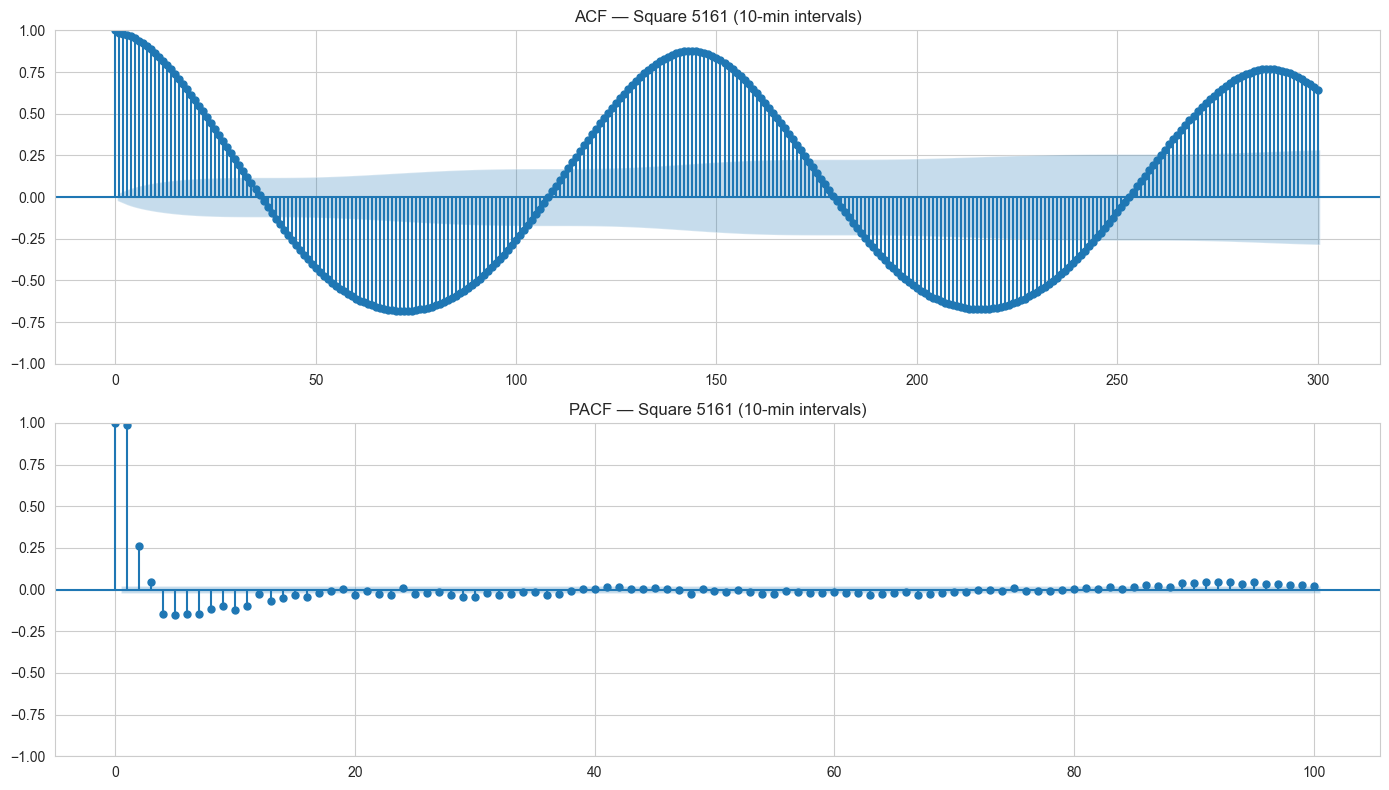


Autocorrelation at key lags:
lag 1 (10 min)       0.9872
lag 6 (1 h)          0.9393
lag 144 (1 day)      0.8930
lag 288 (2 days)     0.8019
lag 1008 (1 week)    0.9292
dtype: float64


In [16]:
# ============================================================
# CELL 14 — ACF / PACF for the highest-traffic area
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts_highest, lags=300, ax=axes[0], alpha=0.05,
        title=f"ACF — Square {highest_id} (10-min intervals)")
plot_pacf(ts_highest, lags=100, ax=axes[1], alpha=0.05,
            title=f"PACF — Square {highest_id} (10-min intervals)")

plt.tight_layout()
plt.savefig(FIG_DIR / "task2_3_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Autocorrelation at key lags ---
lags = [1, 6, 144, 288, 1008]
acf_vals = pd.Series([ts_highest.autocorr(lag=l) for l in lags], index=[
    "lag 1 (10 min)", "lag 6 (1 h)", "lag 144 (1 day)",
    "lag 288 (2 days)", "lag 1008 (1 week)"
])
print("\nAutocorrelation at key lags:")
print(acf_vals.round(4))

In [18]:
from statsmodels.tsa.stattools import adfuller, kpss

adf_out = adfuller(ts_highest, autolag="AIC")
kpss_out = kpss(ts_highest, regression="c", nlags="auto")

print(f"adfuller returns {len(adf_out)} values")
print(f"kpss     returns {len(kpss_out)} values")

adfuller returns 6 values
kpss     returns 4 values


In [20]:
# ============================================================
# CELL 15 — STL decomposition + ADF/KPSS stationarity tests
# (Safe unpacking — works across statsmodels versions)
# ============================================================

stl = STL(ts_highest, period=144, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
axes[0].plot(res.observed, color="black",     linewidth=0.6); axes[0].set_ylabel("Observed")
axes[1].plot(res.trend,    color="steelblue", linewidth=1.0); axes[1].set_ylabel("Trend")
axes[2].plot(res.seasonal, color="green",     linewidth=0.6); axes[2].set_ylabel("Seasonal")
axes[3].plot(res.resid,    color="red",       linewidth=0.4); axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Date")
for ax in axes: ax.grid(True, alpha=0.3)
axes[0].set_title(f"STL Decomposition — Square {highest_id} (period = 144)")

plt.tight_layout()
plt.savefig(FIG_DIR / "task2_3_stl.png", dpi=150, bbox_inches="tight")
plt.show()

var_obs   = np.var(res.observed)
var_resid = np.var(res.resid)
print(f"\nVariance explained by trend + seasonal: {(1 - var_resid/var_obs)*100:.1f}%")
print(f"Residual variance:                     {var_resid:.2f}")

# ------------------------------------------------------------
# Stationarity tests — SAFE UNPACKING
# ------------------------------------------------------------
print("\n" + "=" * 60)
print(f"STATIONARITY TESTS — Square {highest_id}")
print("=" * 60)

# ---- ADF test ----
adf_result = adfuller(ts_highest, autolag="AIC")
# adfuller returns: (adf_stat, pvalue, usedlag, nobs, crit_values, icbest)
adf_stat  = adf_result[0]
adf_p     = adf_result[1]
adf_lags  = adf_result[2]
adf_nobs  = adf_result[3]
adf_crit  = adf_result[4]
adf_icbest = adf_result[5] if len(adf_result) > 5 else None

print(f"\nADF Test:")
print(f"  Statistic:       {adf_stat:.4f}")
print(f"  p-value:         {adf_p:.6f}")
print(f"  Lags used:       {adf_lags}")
print(f"  Observations:    {adf_nobs}")
print(f"  Critical values: {adf_crit}")
if adf_icbest is not None:
    print(f"  IC best:         {adf_icbest:.4f}")
print(f"  → {'Stationary' if adf_p < 0.05 else 'Non-stationary'} at 5%")

# ---- KPSS test ----
# kpss may return 4 or 5 values depending on statsmodels version.
kpss_result = kpss(ts_highest, regression="c", nlags="auto")
kpss_stat  = kpss_result[0]
kpss_p     = kpss_result[1]
kpss_lags  = kpss_result[2]
kpss_crit  = kpss_result[3]

print(f"\nKPSS Test:")
print(f"  Statistic:       {kpss_stat:.4f}")
print(f"  p-value:         {kpss_p:.6f}")
print(f"  Lags used:       {kpss_lags}")
print(f"  Critical values: {kpss_crit}")
print(f"  → {'Stationary' if kpss_p > 0.05 else 'Non-stationary'} at 5%")


Variance explained by trend + seasonal: 86.4%
Residual variance:                     260430.77

STATIONARITY TESTS — Square 5161

ADF Test:
  Statistic:       -19.0319
  p-value:         0.000000
  Lags used:       36
  Observations:    8891
  Critical values: {'1%': np.float64(-3.4310857090295186), '5%': np.float64(-2.861865135161221), '10%': np.float64(-2.56694306444016)}
  IC best:         119174.3270
  → Stationary at 5%

KPSS Test:
  Statistic:       0.2367
  p-value:         0.100000
  Lags used:       56
  Critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  → Stationary at 5%


In [21]:
# ============================================================
# CELL 16 — Tasks 1 & 2 summary
# ============================================================

print("=" * 70)
print("TASK 1 & 2 — SUMMARY")
print("=" * 70)

print(f"\n[TASK 1] Memory optimisation (per daily file):")
print(f"  Naive load:        {naive_mem:.1f} MB")
print(f"  Optimised load:    {opt_mem:.1f} MB")
print(f"  Memory reduction:  {reduction:.1f}%")
print(f"  Parquet size:      {parquet_mb:.1f} MB  ({disk_reduction:.1f}% smaller)")
print(f"  Parquet reload:    {t_pq:.2f} s  ({t_opt / t_pq:.1f}× faster)")

print(f"\n[TASK 2] EDA findings:")
print(f"  Files processed:       {len(txt_files)}")
print(f"  Areas with traffic:    {len(total_traffic):,}")
print(f"  Top 3 areas:           {top3_ids}")
print(f"  Highest-traffic area:  {highest_id}")
print(f"  Distribution skew:     {skew:.2f}")
print(f"  Top 1% traffic share:  {top1_share:.1f}%")
print(f"  Daily seasonality:     period = 144 intervals")
print(f"  ADF  p-value:          {adf_p:.6f}")
print(f"  KPSS p-value:          {kpss_p:.6f}")
print(f"  STL variance explained: {(1 - var_resid/var_obs)*100:.1f}%")

print(f"\n[FIGURES SAVED]")
for p in sorted(FIG_DIR.glob("*.png")):
    print(f"  {p.name}")

print(f"\n[CACHES SAVED]")
for p in sorted(CACHE_DIR.glob("*.parquet")):
    print(f"  {p.name}  ({p.stat().st_size / 1024**2:.1f} MB)")

TASK 1 & 2 — SUMMARY

[TASK 1] Memory optimisation (per daily file):
  Naive load:        295.6 MB
  Optimised load:    157.0 MB
  Memory reduction:  46.9%
  Parquet size:      61.9 MB  (79.9% smaller)
  Parquet reload:    0.17 s  (7.2× faster)

[TASK 2] EDA findings:
  Files processed:       62
  Areas with traffic:    10,000
  Top 3 areas:           [5161, 5059, 5259]
  Highest-traffic area:  5161
  Distribution skew:     4.27
  Top 1% traffic share:  11.0%
  Daily seasonality:     period = 144 intervals
  ADF  p-value:          0.000000
  KPSS p-value:          0.100000
  STL variance explained: 86.4%

[FIGURES SAVED]
  task2_1_distribution.png
  task2_2_time_series_five_areas.png
  task2_3_acf_pacf.png
  task2_3_stl.png

[CACHES SAVED]
  sms-call-internet-mi-2013-11-01.parquet  (61.9 MB)
  sms-call-internet-mi-2013-11-02.parquet  (60.3 MB)
  sms-call-internet-mi-2013-11-03.parquet  (59.7 MB)
  sms-call-internet-mi-2013-11-04.parquet  (67.8 MB)
  sms-call-internet-mi-2013-11-05.parq